# Week 4 — Hidden Markov Models

**Practice task covered**
1. Implement a hidden Markov model (HMM) to predict sequential data: here, the daily **rain sequence**.

Each day is described by one symbol: **0 = dry**, **1 = light rain** (up to 5 mm), **2 = heavy rain** (over 5 mm).
Weather comes in spells: a wet day is likely followed by another wet day. Two models capture this:
* a **Markov chain**: tomorrow depends only on today's symbol;
* a **hidden Markov model**: there is a hidden "weather regime" (e.g. a wet spell or a dry spell) that we never see.
  It changes slowly and decides how likely each symbol is.

Train on 2012–2014, test on 2015. Everything is written from scratch with NumPy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weather import load

d = load()
obs = np.digitize(d.precipitation, [0.001, 5.0]).astype(int)        # 0 dry, 1 light, 2 heavy
n_train = int((d.date < "2015-01-01").sum())                        # first 1,096 days are training
labels = ["dry", "light rain", "heavy rain"]
print("share of training days:", dict(zip(labels, (np.bincount(obs[:n_train], minlength=3) / n_train).round(2).tolist())))
print("train days:", n_train, "| test days:", len(obs) - n_train)

share of training days: {'dry': 0.56, 'light rain': 0.25, 'heavy rain': 0.18}
train days: 1096 | test days: 365


## Step 1 — A Markov chain
Count how often each symbol follows each other symbol. Each row of the table sums to 1.

In [2]:
counts = np.zeros((3, 3))
for today, tomorrow in zip(obs[:n_train - 1], obs[1:n_train]):
    counts[today, tomorrow] += 1
P = counts / counts.sum(1, keepdims=True)
print(pd.DataFrame(P, index="today " + pd.Index(labels), columns="tomorrow " + pd.Index(labels)).round(2))

                  tomorrow dry  tomorrow light rain  tomorrow heavy rain
today dry                 0.76                 0.18                 0.07
today light rain          0.38                 0.36                 0.27
today heavy rain          0.23                 0.35                 0.43


After a dry day, 76% of the time the next day is dry too. After heavy rain, only 23%.

In [3]:
# Evaluate on 2015: predict "rain tomorrow" for each test day t (the answer is day t+1)
t_days = np.arange(n_train, len(obs) - 1)
truth = (obs[t_days + 1] > 0).astype(int)
p_markov = P[obs[t_days], 1:].sum(1)                                 # P(light) + P(heavy) given today's symbol
acc = lambda p: ((p > .5) == truth).mean()
print(f"'tomorrow = today' accuracy: {((obs[t_days] > 0) == truth).mean():.3f}")
print(f"Markov chain accuracy:       {acc(p_markov):.3f}")

'tomorrow = today' accuracy: 0.703
Markov chain accuracy:       0.703


They are identical: after a dry day the chain says "dry" (24% rain), and after any rainy day it says "rain" (over 60%),
which is exactly what "tomorrow = today" says. The chain only adds a probability, not a different answer.

## Step 2 — The HMM algorithms
An HMM has: a hidden state $z_t$ with transition matrix $A$; for each state a table $B$ of how likely each symbol is; and a starting distribution $\pi$.
* **Forward algorithm**: how likely is the sequence, and which state are we probably in *now*?
* **Baum–Welch** (EM): learn $A$, $B$, $\pi$ from the data alone.
* **Viterbi**: the single most likely sequence of hidden states.

In [4]:
def forward(obs, A, B, pi):
    """Scaled forward pass. alpha[t] = P(state at t | symbols up to t). Also returns the log-likelihood."""
    T, K = len(obs), len(pi)
    alpha, c = np.zeros((T, K)), np.zeros(T)
    alpha[0] = pi * B[:, obs[0]]
    c[0] = alpha[0].sum(); alpha[0] /= c[0]
    for t in range(1, T):
        alpha[t] = (alpha[t - 1] @ A) * B[:, obs[t]]
        c[t] = alpha[t].sum(); alpha[t] /= c[t]
    return alpha, c, np.log(c).sum()

def baum_welch(obs, K, M=3, iters=200, seed=0):
    rng = np.random.default_rng(seed)
    A, B = rng.dirichlet(np.ones(K) * 5, K), rng.dirichlet(np.ones(M) * 5, K)   # random start
    pi = np.full(K, 1 / K)
    T = len(obs)
    for _ in range(iters):
        alpha, c, ll = forward(obs, A, B, pi)                        # E-step: forward ...
        beta = np.ones((T, K))
        for t in range(T - 2, -1, -1):                               # ... and backward
            beta[t] = A @ (B[:, obs[t + 1]] * beta[t + 1]) / c[t + 1]
        gamma = alpha * beta; gamma /= gamma.sum(1, keepdims=True)   # P(state at t | all symbols)
        xi = alpha[:-1, :, None] * A[None] * (B[:, obs[1:]].T * beta[1:])[:, None, :]
        xi /= xi.sum((1, 2), keepdims=True)                          # P(state t, state t+1 | all symbols)
        A = xi.sum(0) / gamma[:-1].sum(0)[:, None]                   # M-step: re-estimate everything
        B = np.array([[gamma[obs == m, k].sum() for m in range(M)] for k in range(K)]) / gamma.sum(0)[:, None]
        pi = gamma[0]
    return A, B, pi

def viterbi(obs, A, B, pi):
    T, K = len(obs), len(pi)
    delta, back = np.zeros((T, K)), np.zeros((T, K), int)
    delta[0] = np.log(pi) + np.log(B[:, obs[0]])
    for t in range(1, T):
        scores = delta[t - 1][:, None] + np.log(A)
        back[t], delta[t] = scores.argmax(0), scores.max(0) + np.log(B[:, obs[t]])
    path = [delta[-1].argmax()]
    for t in range(T - 1, 0, -1):
        path.append(back[t, path[-1]])
    return np.array(path[::-1])

### Check the code against brute force
On a short sequence we can add up the probability of *every* possible hidden path. The forward algorithm must give the same answer.

In [5]:
import itertools
A0 = np.array([[.8, .2], [.3, .7]]); B0 = np.array([[.7, .2, .1], [.1, .4, .5]]); pi0 = np.array([.6, .4])
short = obs[:6]
brute = sum(pi0[z[0]] * B0[z[0], short[0]] * np.prod([A0[z[i - 1], z[i]] * B0[z[i], short[i]] for i in range(1, 6)])
            for z in itertools.product(range(2), repeat=6))
print("brute force:", round(np.log(brute), 6), "| forward algorithm:", round(forward(short, A0, B0, pi0)[2], 6))

brute force: -7.025052 | forward algorithm: -7.025052


## Step 3 — Learn an HMM and choose the number of hidden states
Baum–Welch can get stuck, so run it from 5 random starts and keep the best. **BIC** (lower is better) decides how many states,
using the training data only.

In [6]:
train_obs = obs[:n_train]
fits, rows = {}, []
for K in [1, 2, 3, 4]:
    best = max((baum_welch(train_obs, K, seed=s) for s in range(5)), key=lambda m: forward(train_obs, *m)[2])
    ll = forward(train_obs, *best)[2]
    n_params = K * (K - 1) + K * 2 + (K - 1)
    fits[K] = best
    rows.append({"hidden states": K, "log-likelihood": round(ll, 1), "BIC": round(-2 * ll + n_params * np.log(n_train), 1)})
pd.DataFrame(rows).set_index("hidden states")

,log-likelihood,BIC
hidden states,,
1,-1077.1,2168.2
2,-938.9,1926.7
3,-924.0,1946.1
4,-921.9,2004.8


BIC is lowest for **2 hidden states**: one regime is not enough, and more regimes do not add enough to pay for their extra parameters.

In [7]:
A, B, pi = fits[2]
order = np.argsort(B[:, 0])                  # put the wetter state first
A, B, pi = A[np.ix_(order, order)], B[order], pi[order]
state_names = ["wet spell", "dry spell"]
print("transition matrix (row = from):"); print(pd.DataFrame(A, index=state_names, columns=state_names).round(2))
print("\nwhat each state produces:"); print(pd.DataFrame(B, index=state_names, columns=labels).round(2))
print("\naverage length of a spell (days):", dict(zip(state_names, (1 / (1 - np.diag(A))).round(1).tolist())))

transition matrix (row = from):
           wet spell  dry spell
wet spell       0.88       0.12
dry spell       0.12       0.88

what each state produces:
            dry  light rain  heavy rain
wet spell  0.19        0.44        0.37
dry spell  0.93        0.07        0.00

average length of a spell (days): {'wet spell': 8.2, 'dry spell': 8.6}


The model found two regimes on its own: a **wet spell** (mostly rainy days, often heavy) and a **dry spell** (almost always dry),
each lasting about a week on average. We never told it about wet or dry spells.

### What are the hidden states? Check against data the model never saw
The model only saw the rain symbols. If the states are real weather regimes, they should also differ in wind and temperature.

In [8]:
alpha_all, c_all, _ = forward(obs, A, B, pi)
path = viterbi(obs, A, B, pi)
check = d.assign(state=np.array(state_names)[path]).groupby("state")[["wind", "temp_max", "rain"]].mean().round(2)
check

,wind,temp_max,rain
state,,,
dry spell,2.89,19.88,0.06
wet spell,3.62,12.72,0.82


The wet spell has stronger wind (3.6 vs 2.9) and cooler days (12.7 vs 19.9 °C): the regimes line up with real weather the model never saw.
Part of that gap is simply winter being wetter than summer, so the regimes are partly seasonal.

### Viterbi: the most likely sequence of regimes in 2015

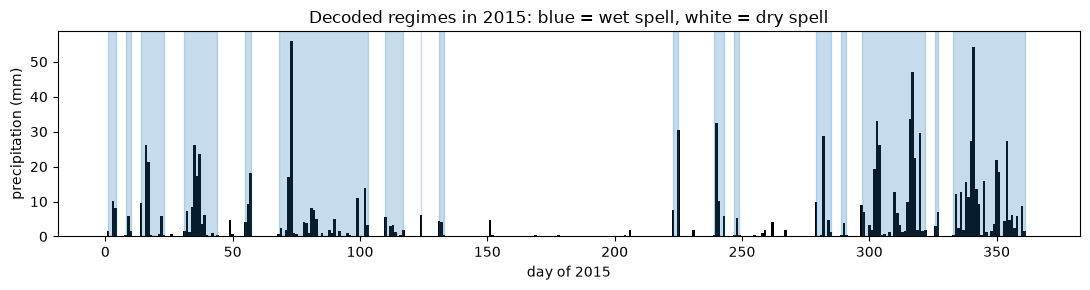

In [9]:
year = slice(n_train, len(obs))
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(len(obs) - n_train), d.precipitation.values[year], color="k", width=1)
ax.fill_between(range(len(obs) - n_train), 0, 1, where=path[year] == 0, color="tab:blue", alpha=.25, transform=ax.get_xaxis_transform(), label="wet spell")
ax.set_xlabel("day of 2015"); ax.set_ylabel("precipitation (mm)"); ax.set_title("Decoded regimes in 2015: blue = wet spell, white = dry spell")
plt.tight_layout(); plt.show()

## Step 4 — Predict tomorrow
Walk through 2015 one day at a time. Each morning the forward algorithm tells us how likely each regime is *today*;
the transition matrix moves that one day ahead; the regime's table gives the chance of rain.

In [10]:
p_hmm = (alpha_all[t_days] @ A @ B)[:, 1:].sum(1)               # P(rain tomorrow) from the filtered state
print(f"'tomorrow = today' accuracy: {((obs[t_days] > 0) == truth).mean():.3f}")
print(f"Markov chain accuracy:       {acc(p_markov):.3f}")
print(f"HMM accuracy:                {acc(p_hmm):.3f}")
eps = 1e-9
logloss = lambda p: -np.mean(truth * np.log(p + eps) + (1 - truth) * np.log(1 - p + eps))
print(f"\nlog-loss (lower is better): Markov chain {logloss(p_markov):.3f} | HMM {logloss(p_hmm):.3f}")

'tomorrow = today' accuracy: 0.703
Markov chain accuracy:       0.703
HMM accuracy:                0.687

log-loss (lower is better): Markov chain 0.598 | HMM 0.593


## Summary
* Rain comes in spells. The HMM discovered a wet and a dry regime without being told about them, and the regimes match wind and temperature.
* For predicting tomorrow, the HMM (68.7%) does **not** beat "tomorrow = today" (70.3%), and its log-loss is only marginally better than the
  Markov chain's. A regime that lasts about a week adds little over simply looking at today.
* The forward algorithm was checked against brute force before being trusted.